In [1]:
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


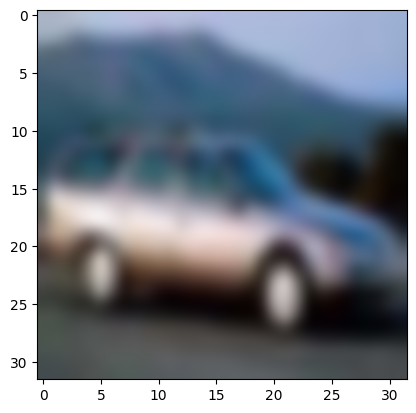

In [7]:
image = x_train[4]
plt.imshow(image, interpolation='bicubic')
plt.show()

In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [10]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [11]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [12]:
modelo = Sequential()

modelo.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
modelo.add(Conv2D(32, (3, 3), activation='relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2)))
modelo.add(Dropout(0.25))

modelo.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo.add(Conv2D(64, (3, 3), activation='relu'))
modelo.add(MaxPooling2D(pool_size=(2, 2)))
modelo.add(Dropout(0.25))

modelo.add(Flatten())
modelo.add(Dense(512, activation='relu'))
modelo.add(Dropout(0.25))
modelo.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
modelo.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
modelo.fit(x_train, y_train, batch_size=32, epochs=100, validation_data=(x_test, y_test))

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.4692 - loss: 1.4579 - val_accuracy: 0.6052 - val_loss: 1.1108
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6265 - loss: 1.0567 - val_accuracy: 0.6848 - val_loss: 0.8900
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6808 - loss: 0.9049 - val_accuracy: 0.7272 - val_loss: 0.7964
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7181 - loss: 0.8019 - val_accuracy: 0.7357 - val_loss: 0.7570
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7425 - loss: 0.7319 - val_accuracy: 0.7494 - val_loss: 0.7228
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7628 - loss: 0.6695 - val_accuracy: 0.7600 - val_loss: 0.6952
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7809 - loss: 0.6248 - val_accuracy: 0.7703 - val_loss: 0.6767
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7952 - loss:

In [15]:
previsoes = modelo.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
previsoes

array([[1.8362753e-04, 2.2608251e-04, 7.0566515e-04, ..., 1.3905406e-04,
        2.1042633e-03, 6.4741922e-05],
       [3.1544937e-07, 3.6395885e-04, 1.4954734e-23, ..., 1.4611972e-25,
        9.9963403e-01, 1.6768023e-06],
       [1.5330774e-04, 2.1534540e-06, 2.5675642e-11, ..., 4.6765153e-12,
        9.9976605e-01, 7.8380755e-05],
       ...,
       [4.0764337e-15, 3.4470122e-18, 7.4242060e-08, ..., 2.1367394e-07,
        7.1468021e-13, 1.4078678e-18],
       [1.4942444e-06, 9.9948704e-01, 1.5783111e-07, ..., 5.5177005e-09,
        2.2540125e-07, 3.0449808e-08],
       [2.7766398e-20, 7.8659589e-25, 3.4403416e-19, ..., 1.0000000e+00,
        1.6550753e-20, 1.7935388e-22]], dtype=float32)

In [17]:
previsoes_classes = np.argmax(previsoes, axis=1)
previsoes_classes

array([3, 8, 8, ..., 5, 1, 7])

In [18]:
y_test_classes = np.argmax(y_test, axis=1)
y_test_classes

array([3, 8, 8, ..., 5, 1, 7])

In [20]:
accuracy = accuracy_score(y_test_classes, previsoes_classes)
accuracy

0.7812

In [21]:
confusion = confusion_matrix(y_test_classes, previsoes_classes)
confusion

array([[831,  10,  32,  15,  17,   9,   4,  12,  44,  26],
       [ 15, 892,   1,   6,   3,   6,   3,   3,  18,  53],
       [ 70,   2, 648,  61,  73,  48,  50,  25,  15,   8],
       [ 24,   6,  64, 623,  61, 103,  61,  30,  16,  12],
       [ 17,   2,  44,  59, 759,  31,  41,  36,   8,   3],
       [ 13,   3,  46, 174,  33, 654,  31,  30,   9,   7],
       [  7,   4,  38,  44,  29,   7, 860,   4,   5,   2],
       [ 15,   2,  17,  32,  49,  47,   8, 820,   4,   6],
       [ 53,  17,   6,  14,   5,   7,   2,   1, 881,  14],
       [ 25,  57,   5,  11,   6,   8,  10,   7,  27, 844]])